# KV Cache Compression Benchmark on LongBench

This notebook is designed for **Google Colab with A100 GPU** and benchmarks KV-cache compression methods on **`Qwen/Qwen2.5-1.5B-Instruct`**.

## Methods in scope
- `baseline`
- `streamingllm`
- `snapkv`
- `h2o`
- `knorm`
- `razorattention` (locked to the paper, custom implementation still pending)

## Paper lock-in
- `KNorm`: [A Simple and Effective L2 Norm-Based Strategy for KV Cache Compression](https://aclanthology.org/2024.emnlp-main.1027/)
- `RazorAttention`: [RazorAttention: Efficient KV Cache Compression Through Retrieval Heads](https://arxiv.org/abs/2407.15891)

## Notes
- This notebook uses `kvpress` for the methods it already implements.
- `KVZap` was removed from the runnable Colab flow because the required public model assets were not available for this setup.
- `RazorAttention` is left as a placeholder because no solid public implementation was found during setup.
- The benchmark is designed so you can first do a **small smoke test** and then scale to the full run.

In [ ]:
# Colab install cell
# If flash-attn installation gives trouble in your runtime, remove it and keep kvpress only.

!pip -q install -U pip
!pip -q install transformers accelerate datasets sentencepiece rouge-score matplotlib tqdm pandas huggingface_hub
!pip -q install kvpress

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [ ]:
import gc
import json
import re
import time
import zipfile
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from rouge_score import rouge_scorer
from tqdm.auto import tqdm
from transformers import pipeline

import kvpress
from kvpress import KnormPress, ObservedAttentionPress, SnapKVPress, StreamingLLMPress

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
TASKS = [
    "narrativeqa",
    "qasper",
    "multifieldqa_en",
    "gov_report",
    "hotpotqa",
    "2wikimqa",
]

# Start small for a smoke test, then increase to 25 or 50.
MAX_EXAMPLES_PER_TASK = 5
MAX_NEW_TOKENS = 32
BUDGETS = [0.5, 0.2, 0.1]
METHODS = ["baseline", "streamingllm", "snapkv", "h2o", "knorm", "razorattention"]

OUTPUT_DIR = Path("/content/kvpress_longbench_outputs")
DATA_DIR = Path("/content/longbench_data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

DEVICE_INFO = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE_INFO)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

METHOD_INFO = {
    "baseline": {"paper": "", "impl": "full KV cache"},
    "streamingllm": {"paper": "https://arxiv.org/abs/2309.17453", "impl": "kvpress.StreamingLLMPress"},
    "snapkv": {"paper": "https://arxiv.org/abs/2404.14469", "impl": "kvpress.SnapKVPress"},
    "h2o": {"paper": "https://arxiv.org/abs/2306.14048", "impl": "kvpress.ObservedAttentionPress"},
    "knorm": {"paper": "https://aclanthology.org/2024.emnlp-main.1027/", "impl": "kvpress.KnormPress"},
    "razorattention": {"paper": "https://arxiv.org/abs/2407.15891", "impl": "custom from paper"},
}

_ROUGE = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

device: cuda
gpu: NVIDIA A100-SXM4-80GB


In [ ]:
def normalize_text(text):
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text


def f1_score_text(prediction, gold):
    pred_tokens = normalize_text(prediction).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0

    common = defaultdict(int)
    for token in gold_tokens:
        common[token] += 1

    overlap = 0
    for token in pred_tokens:
        if common[token] > 0:
            overlap += 1
            common[token] -= 1

    if overlap == 0:
        return 0.0

    precision = overlap / len(pred_tokens)
    recall = overlap / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)


def rouge_l(prediction, gold):
    return _ROUGE.score(gold, prediction)["rougeL"].fmeasure


def score_prediction(task_name, prediction, answers):
    if isinstance(answers, str):
        answers = [answers]
    answers = answers or [""]

    if task_name == "gov_report":
        return max(rouge_l(prediction, answer) for answer in answers), "rougeL"
    return max(f1_score_text(prediction, answer) for answer in answers), "f1"


def get_field(example, names, default=""):
    for name in names:
        if name in example and example[name] is not None:
            return example[name]
    return default


def ensure_longbench_data(data_dir=DATA_DIR):
    extract_dir = data_dir / "raw"
    if (extract_dir / "data").exists():
        return extract_dir

    zip_path = hf_hub_download(
        repo_id="THUDM/LongBench",
        repo_type="dataset",
        filename="data.zip",
    )

    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    return extract_dir


def load_longbench_task(task_name, max_examples, base_dir):
    candidates = list(base_dir.rglob(f"{task_name}.jsonl"))
    if not candidates:
        raise FileNotFoundError(f"Could not find {task_name}.jsonl under {base_dir}")

    dataset = load_dataset("json", data_files=str(candidates[0]), split="train")
    if max_examples > 0:
        dataset = dataset.select(range(min(max_examples, len(dataset))))
    return dataset


def build_press(method_name, compression_ratio):
    if method_name == "baseline":
        return None
    if method_name == "streamingllm":
        return StreamingLLMPress(compression_ratio=compression_ratio)
    if method_name == "snapkv":
        return SnapKVPress(compression_ratio=compression_ratio)
    if method_name == "h2o":
        return ObservedAttentionPress(compression_ratio=compression_ratio)
    if method_name == "knorm":
        return KnormPress(compression_ratio=compression_ratio)
    if method_name == "razorattention":
        raise NotImplementedError(
            "RazorAttention is locked to https://arxiv.org/abs/2407.15891 but still needs a custom implementation."
        )
    raise ValueError(f"Unsupported method: {method_name}")


def extract_answer_text(raw_output):
    if isinstance(raw_output, dict):
        if "answer" in raw_output:
            return raw_output["answer"]
        if "generated_text" in raw_output:
            return raw_output["generated_text"]
    if isinstance(raw_output, list) and raw_output:
        return extract_answer_text(raw_output[0])
    raise ValueError(f"Unexpected pipeline output type: {type(raw_output)}")

In [ ]:
# Build kvpress pipeline around Qwen2.5-1.5B-Instruct.
# H2O in kvpress maps to ObservedAttentionPress, which needs attention tensors.
# That requires attn_implementation="eager" instead of flash/sdpa.

pipe = pipeline(
    "kv-press-text-generation",
    model=MODEL_ID,
    device_map="auto",
    dtype="auto",
    model_kwargs={"attn_implementation": "eager"},
)

tokenizer = pipe.tokenizer
print("Pipeline ready for", MODEL_ID, "with attn_implementation=eager")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Pipeline ready for Qwen/Qwen2.5-1.5B-Instruct with attn_implementation=eager


In [ ]:
extract_dir = ensure_longbench_data(DATA_DIR)
datasets_map = {
    task_name: load_longbench_task(task_name, MAX_EXAMPLES_PER_TASK, extract_dir)
    for task_name in TASKS
}

for task_name in TASKS:
    print(task_name, len(datasets_map[task_name]))

data.zip:   0%|          | 0.00/114M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

narrativeqa 5
qasper 5
multifieldqa_en 5
gov_report 5
hotpotqa 5
2wikimqa 5


In [ ]:
def run_one_example(task_name, example, method_name, kv_budget):
    context = get_field(example, ["context", "article", "passage"], "")
    question = get_field(example, ["input", "question", "query", "instruction"], "")
    answers = get_field(example, ["answers", "answer"], [])
    if isinstance(answers, str):
        answers = [answers]

    press = build_press(method_name, kv_budget)
    kwargs = {
        "question": question,
        "max_new_tokens": MAX_NEW_TOKENS,
    }
    if press is not None:
        kwargs["press"] = press

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start = time.perf_counter()
    raw_output = pipe(context, **kwargs)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    latency = time.perf_counter() - start

    prediction = extract_answer_text(raw_output)
    generated_tokens = len(tokenizer(prediction, add_special_tokens=False)["input_ids"])
    score, metric = score_prediction(task_name, prediction, answers)

    peak_memory_gb = None
    if torch.cuda.is_available():
        peak_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)

    return {
        "task": task_name,
        "method": method_name,
        "kv_budget": kv_budget,
        "metric": metric,
        "score": score,
        "latency": latency,
        "tokens_per_sec": generated_tokens / max(latency, 1e-6),
        "generated_tokens": generated_tokens,
        "peak_memory_gb": peak_memory_gb,
        "prediction": prediction,
        "answers": json.dumps(answers, ensure_ascii=False),
        "paper_url": METHOD_INFO[method_name]["paper"],
        "implementation": METHOD_INFO[method_name]["impl"],
    }


def run_benchmark(tasks=TASKS, methods=METHODS, budgets=BUDGETS, skip_unimplemented=True):
    all_rows = []
    skipped = []

    for task_name in tasks:
        ds = datasets_map[task_name]
        for method_name in methods:
            method_budgets = [1.0] if method_name == "baseline" else budgets
            for budget in method_budgets:
                print(f"\n=== task={task_name} method={method_name} budget={budget} ===")
                skip_method = False
                for example_id, example in enumerate(tqdm(ds, total=len(ds))):
                    try:
                        row = run_one_example(task_name, example, method_name, budget)
                        row["example_id"] = example_id
                        all_rows.append(row)
                    except NotImplementedError as exc:
                        if skip_unimplemented:
                            skipped.append({"method": method_name, "reason": str(exc)})
                            print("Skipping:", method_name, "->", exc)
                            skip_method = True
                            break
                        raise
                    except RuntimeError as exc:
                        print(f"RuntimeError on task={task_name} example={example_id} method={method_name} budget={budget}: {exc}")
                        if torch.cuda.is_available():
                            torch.cuda.empty_cache()
                if skip_method:
                    break

    results_df = pd.DataFrame(all_rows)
    skipped_df = pd.DataFrame(skipped)
    return results_df, skipped_df

In [ ]:
# Smoke-test suggestion for Colab:
# Keep MAX_EXAMPLES_PER_TASK small first, confirm the pipeline works,
# then bump to 25 or 50 for the final run.

results_df, skipped_df = run_benchmark()
print("rows:", len(results_df))
if not skipped_df.empty:
    display(skipped_df.drop_duplicates())

results_df.head()


=== task=narrativeqa method=baseline budget=1.0 ===


  0%|          | 0/5 [00:00<?, ?it/s]

RuntimeError on task=narrativeqa example=0 method=baseline budget=1.0: CUDA out of memory. Tried to allocate 43.85 GiB. GPU 0 has a total capacity of 79.25 GiB of which 7.20 GiB is free. Including non-PyTorch memory, this process has 72.04 GiB memory in use. Of the allocated memory 70.98 GiB is allocated by PyTorch, and 572.08 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
RuntimeError on task=narrativeqa example=1 method=baseline budget=1.0: CUDA out of memory. Tried to allocate 43.97 GiB. GPU 0 has a total capacity of 79.25 GiB of which 7.02 GiB is free. Including non-PyTorch memory, this process has 72.22 GiB memory in use. Of the allocated memory 71.16 GiB is allocated by PyTorch, and 573.73 MiB is reserved by PyTorch but unallocated. If reserved but 

  0%|          | 0/5 [00:00<?, ?it/s]

RuntimeError on task=narrativeqa example=0 method=streamingllm budget=0.5: CUDA out of memory. Tried to allocate 43.85 GiB. GPU 0 has a total capacity of 79.25 GiB of which 7.20 GiB is free. Including non-PyTorch memory, this process has 72.04 GiB memory in use. Of the allocated memory 70.98 GiB is allocated by PyTorch, and 572.08 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
RuntimeError on task=narrativeqa example=1 method=streamingllm budget=0.5: CUDA out of memory. Tried to allocate 43.97 GiB. GPU 0 has a total capacity of 79.25 GiB of which 7.02 GiB is free. Including non-PyTorch memory, this process has 72.22 GiB memory in use. Of the allocated memory 71.16 GiB is allocated by PyTorch, and 573.73 MiB is reserved by PyTorch but unallocated. If reser

...


=== task=2wikimqa method=razorattention budget=0.5 ===


  0%|          | 0/5 [00:00<?, ?it/s]

Skipping: razorattention -> RazorAttention is locked to https://arxiv.org/abs/2407.15891 but still needs a custom implementation.
rows: 351


,method,reason
0,razorattention,RazorAttention is locked to https://arxiv.org/...


,task,method,kv_budget,metric,score,latency,tokens_per_sec,generated_tokens,peak_memory_gb,prediction,answers,paper_url,implementation,example_id
0,narrativeqa,baseline,1.0,f1,0.333333,1.997748,5.506200,11,11.094325,The witch lives in a cave on Atlas' mountain.,"[""The Atlas Mountains""]",,full KV cache,2
1,narrativeqa,baseline,1.0,f1,0.368421,2.555631,12.521372,32,12.456715,Crito's visit was primarily to bring Socrates ...,"[""To smuggle Socrates out of prison and into a...",,full KV cache,3
2,narrativeqa,streamingllm,0.5,f1,0.062500,2.765936,11.569322,32,10.987373,"Based on the passage, the witch lives in a hav...","[""The Atlas Mountains""]",https://arxiv.org/abs/2309.17453,kvpress.StreamingLLMPress,2
3,narrativeqa,streamingllm,0.5,f1,0.111111,2.554125,12.528752,32,12.341035,Crito's visit was likely to persuade Socrates ...,"[""To smuggle Socrates out of prison and into a...",https://arxiv.org/abs/2309.17453,kvpress.StreamingLLMPress,3
4,narrativeqa,streamingllm,0.2,f1,0.066667,3.622632,8.833356,32,11.073017,"Based on the passage, the witch lives in a wil...","[""The Atlas Mountains""]",https://arxiv.org/abs/2309.17453,kvpress.StreamingLLMPress,2


In [ ]:
raw_path = OUTPUT_DIR / "raw_results.csv"
summary_path = OUTPUT_DIR / "task_summary.csv"
overall_path = OUTPUT_DIR / "overall_summary.csv"
manifest_path = OUTPUT_DIR / "run_manifest.json"

results_df.to_csv(raw_path, index=False)

summary_df = (
    results_df.groupby(["task", "method", "kv_budget", "metric"], as_index=False)
    .agg(
        score_mean=("score", "mean"),
        latency_mean=("latency", "mean"),
        tps_mean=("tokens_per_sec", "mean"),
        generated_tokens_mean=("generated_tokens", "mean"),
        peak_memory_gb_mean=("peak_memory_gb", "mean"),
    )
    .sort_values(["task", "method", "kv_budget"])
)
summary_df.to_csv(summary_path, index=False)

overall_df = (
    results_df.groupby(["method", "kv_budget"], as_index=False)
    .agg(
        score_mean=("score", "mean"),
        latency_mean=("latency", "mean"),
        tps_mean=("tokens_per_sec", "mean"),
        generated_tokens_mean=("generated_tokens", "mean"),
        peak_memory_gb_mean=("peak_memory_gb", "mean"),
    )
    .sort_values(["method", "kv_budget"])
)
overall_df.to_csv(overall_path, index=False)

manifest = {
    "model_id": MODEL_ID,
    "tasks": TASKS,
    "methods": METHODS,
    "budgets": BUDGETS,
    "max_examples_per_task": MAX_EXAMPLES_PER_TASK,
    "max_new_tokens": MAX_NEW_TOKENS,
    "method_info": METHOD_INFO,
}
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved:", raw_path)
print("Saved:", summary_path)
print("Saved:", overall_path)
print("Saved:", manifest_path)

display(summary_df.head())
display(overall_df)

Saved: /content/kvpress_longbench_outputs/raw_results.csv
Saved: /content/kvpress_longbench_outputs/task_summary.csv
Saved: /content/kvpress_longbench_outputs/overall_summary.csv
Saved: /content/kvpress_longbench_outputs/run_manifest.json


,task,method,kv_budget,metric,score_mean,latency_mean,tps_mean,generated_tokens_mean,peak_memory_gb_mean
0,2wikimqa,baseline,1.0,f1,0.030286,2.335766,14.140466,32.0,11.033363
1,2wikimqa,h2o,0.1,f1,0.030286,2.400280,13.715678,31.8,11.022118
2,2wikimqa,h2o,0.2,f1,0.030286,2.390286,13.872412,32.0,11.005376
3,2wikimqa,h2o,0.5,f1,0.030460,2.373983,13.947358,32.0,10.929681
4,2wikimqa,knorm,0.1,f1,0.016000,2.341730,14.106855,32.0,11.022118


,method,kv_budget,score_mean,latency_mean,tps_mean,generated_tokens_mean,peak_memory_gb_mean
0,baseline,1.0,0.167403,2.779727,12.880014,30.074074,15.729158
1,h2o,0.1,0.173184,2.896297,12.579390,30.037037,15.716212
2,h2o,0.2,0.170165,2.943316,12.741400,30.851852,15.689571
3,h2o,0.5,0.151531,2.872419,12.703642,30.148148,15.607966
4,knorm,0.1,0.149380,2.931573,13.093263,32.000000,15.716212
5,knorm,0.2,0.136225,2.931647,13.119225,32.000000,15.689571
6,knorm,0.5,0.130070,2.902753,13.119524,32.000000,15.607966
7,snapkv,0.1,0.176220,2.810729,12.814890,30.074074,15.716212
8,snapkv,0.2,0.166507,2.825141,12.750966,30.074074,15.689571
9,snapkv,0.5,0.155190,2.899511,12.920078,31.370370,15.607966


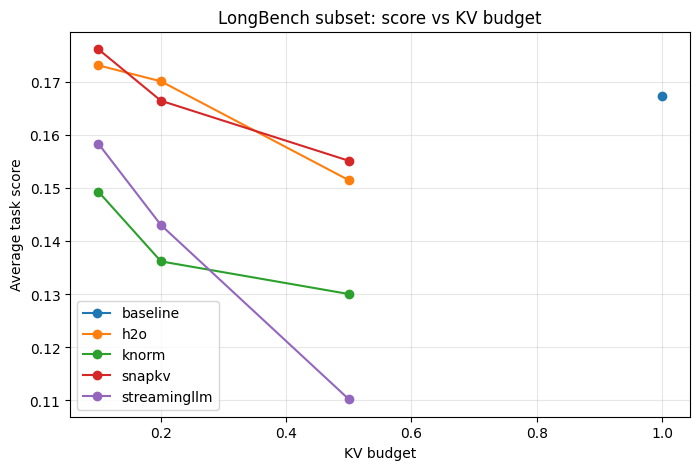

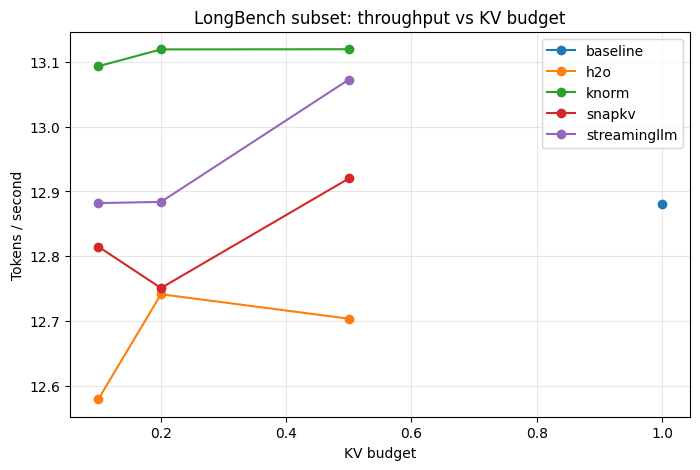

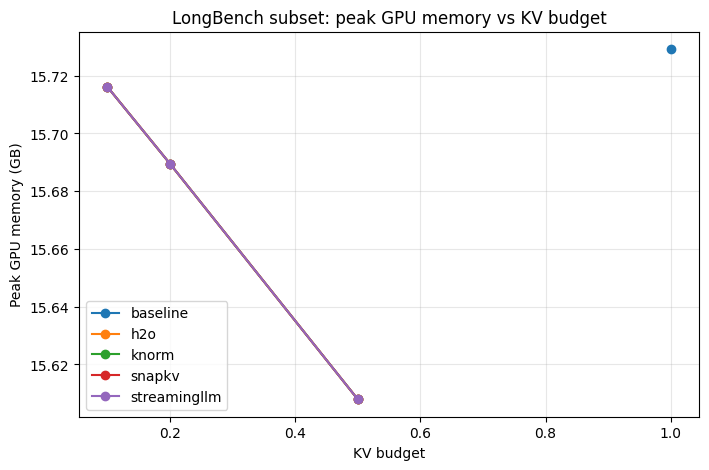

In [ ]:
plt.figure(figsize=(8, 5))
for method in overall_df["method"].unique():
    sub = overall_df[overall_df["method"] == method].sort_values("kv_budget")
    plt.plot(sub["kv_budget"], sub["score_mean"], marker="o", label=method)
plt.xlabel("KV budget")
plt.ylabel("Average task score")
plt.title("LongBench subset: score vs KV budget")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
for method in overall_df["method"].unique():
    sub = overall_df[overall_df["method"] == method].sort_values("kv_budget")
    plt.plot(sub["kv_budget"], sub["tps_mean"], marker="o", label=method)
plt.xlabel("KV budget")
plt.ylabel("Tokens / second")
plt.title("LongBench subset: throughput vs KV budget")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

if overall_df["peak_memory_gb_mean"].notna().any():
    plt.figure(figsize=(8, 5))
    for method in overall_df["method"].unique():
        sub = overall_df[overall_df["method"] == method].sort_values("kv_budget")
        plt.plot(sub["kv_budget"], sub["peak_memory_gb_mean"], marker="o", label=method)
    plt.xlabel("KV budget")
    plt.ylabel("Peak GPU memory (GB)")
    plt.title("LongBench subset: peak GPU memory vs KV budget")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## RazorAttention Placeholder

`RazorAttention` is intentionally present in the benchmark list, but the notebook skips it for now.

Why it is skipped:
- the paper is locked to [RazorAttention: Efficient KV Cache Compression Through Retrieval Heads](https://arxiv.org/abs/2407.15891)
- no solid public implementation was found during setup
- the method needs a custom implementation from the paper before it can be benchmarked fairly alongside the `kvpress` methods

## Recommended run order in Colab
1. Run the notebook with `MAX_EXAMPLES_PER_TASK = 5`
2. Confirm `baseline`, `streamingllm`, `snapkv`, `h2o`, and `knorm` all run cleanly
3. Increase to `25` or `50`
4. Add custom `RazorAttention` once implemented

## Final project framing
- Reference methods: `StreamingLLM`, `SnapKV`, `H2O`
- Assigned methods: `KNorm`, `RazorAttention`
- `KVZap` is documented but removed from the runnable Colab notebook because the required public assets were not available in this setup
- Common model: `Qwen/Qwen2.5-1.5B-Instruct`
- Common benchmark: LongBench subset
- Core tradeoff: accuracy vs speed vs memory under fixed KV budgets

In [ ]:
# Final-run configuration.
# If you want the strongest final table overnight, use 50 examples.
# If runtime is too long, drop to 25.

FINAL_TASKS = TASKS
FINAL_METHODS = ["baseline", "streamingllm", "snapkv", "h2o", "knorm"]
FINAL_KEEP_RATIOS = [0.5, 0.2, 0.1]
FINAL_MAX_EXAMPLES_PER_TASK = 50
FINAL_MAX_NEW_TOKENS = MAX_NEW_TOKENS
FINAL_RUN_NAME = "final_keep_ratio_run"
FINAL_OUTPUT_DIR = OUTPUT_DIR / FINAL_RUN_NAME
FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Final methods:", FINAL_METHODS)
print("Keep ratios:", FINAL_KEEP_RATIOS)
print("Compression ratios:", [round(1.0 - x, 3) for x in FINAL_KEEP_RATIOS])
print("Examples per task:", FINAL_MAX_EXAMPLES_PER_TASK)
print("Output dir:", FINAL_OUTPUT_DIR)

Final methods: ['baseline', 'streamingllm', 'snapkv', 'h2o', 'knorm']
Keep ratios: [0.5, 0.2, 0.1]
Compression ratios: [0.5, 0.8, 0.9]
Examples per task: 50
Output dir: /content/kvpress_longbench_outputs/final_keep_ratio_run


In [ ]:
def keep_ratio_to_compression_ratio(keep_ratio):
    return max(0.0, min(1.0, 1.0 - keep_ratio))


def build_press_from_keep_ratio(method_name, keep_ratio):
    if method_name == "baseline":
        return None
    compression_ratio = keep_ratio_to_compression_ratio(keep_ratio)
    return build_press(method_name, compression_ratio)


def final_result_key(task_name, method_name, keep_ratio, example_id):
    return (str(task_name), str(method_name), float(keep_ratio), int(example_id))


def load_existing_keys(raw_results_path):
    if not raw_results_path.exists():
        return set()
    existing_df = pd.read_csv(raw_results_path)
    keys = set()
    for _, row in existing_df.iterrows():
        keys.add(final_result_key(row["task"], row["method"], row["keep_ratio"], row["example_id"]))
    return keys


def append_row_to_csv(row, csv_path):
    row_df = pd.DataFrame([row])
    row_df.to_csv(csv_path, mode="a", header=not csv_path.exists(), index=False)


def refresh_final_summaries(raw_results_path, output_dir):
    if not raw_results_path.exists():
        return None, None, None

    all_results_df = pd.read_csv(raw_results_path)
    ok_df = all_results_df[all_results_df["status"] == "ok"].copy()

    if ok_df.empty:
        status_df = (
            all_results_df.groupby(["task", "method", "keep_ratio", "status"], as_index=False)
            .size()
            .rename(columns={"size": "count"})
        )
        status_df.to_csv(output_dir / "status_summary.csv", index=False)
        return all_results_df, None, status_df

    summary_df = (
        ok_df.groupby(["task", "method", "keep_ratio", "compression_ratio", "metric"], as_index=False)
        .agg(
            score_mean=("score", "mean"),
            score_std=("score", "std"),
            latency_mean=("latency", "mean"),
            tps_mean=("tokens_per_sec", "mean"),
            generated_tokens_mean=("generated_tokens", "mean"),
            peak_memory_gb_mean=("peak_memory_gb", "mean"),
            success_count=("status", "count"),
        )
        .sort_values(["task", "method", "keep_ratio"])
    )

    overall_df = (
        ok_df.groupby(["method", "keep_ratio", "compression_ratio"], as_index=False)
        .agg(
            score_mean=("score", "mean"),
            score_std=("score", "std"),
            latency_mean=("latency", "mean"),
            tps_mean=("tokens_per_sec", "mean"),
            generated_tokens_mean=("generated_tokens", "mean"),
            peak_memory_gb_mean=("peak_memory_gb", "mean"),
            success_count=("status", "count"),
        )
        .sort_values(["method", "keep_ratio"])
    )

    status_df = (
        all_results_df.groupby(["task", "method", "keep_ratio", "status"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
        .sort_values(["task", "method", "keep_ratio", "status"])
    )

    summary_df.to_csv(output_dir / "task_summary.csv", index=False)
    overall_df.to_csv(output_dir / "overall_summary.csv", index=False)
    status_df.to_csv(output_dir / "status_summary.csv", index=False)

    task_pivot = summary_df.pivot_table(index=["task"], columns=["method", "keep_ratio"], values="score_mean")
    task_pivot.to_csv(output_dir / "task_score_pivot.csv")

    return all_results_df, overall_df, status_df


def run_one_example_final(task_name, example, method_name, keep_ratio):
    context = get_field(example, ["context", "article", "passage"], "")
    question = get_field(example, ["input", "question", "query", "instruction"], "")
    answers = get_field(example, ["answers", "answer"], [])
    if isinstance(answers, str):
        answers = [answers]

    press = build_press_from_keep_ratio(method_name, keep_ratio)
    kwargs = {
        "question": question,
        "max_new_tokens": FINAL_MAX_NEW_TOKENS,
    }
    if press is not None:
        kwargs["press"] = press

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    start = time.perf_counter()
    raw_output = pipe(context, **kwargs)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    latency = time.perf_counter() - start

    prediction = extract_answer_text(raw_output)
    generated_tokens = len(tokenizer(prediction, add_special_tokens=False)["input_ids"])
    score, metric = score_prediction(task_name, prediction, answers)

    peak_memory_gb = None
    if torch.cuda.is_available():
        peak_memory_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)

    return {
        "task": task_name,
        "method": method_name,
        "keep_ratio": keep_ratio,
        "compression_ratio": keep_ratio_to_compression_ratio(keep_ratio),
        "metric": metric,
        "score": score,
        "latency": latency,
        "tokens_per_sec": generated_tokens / max(latency, 1e-6),
        "generated_tokens": generated_tokens,
        "peak_memory_gb": peak_memory_gb,
        "prediction": prediction,
        "answers": json.dumps(answers, ensure_ascii=False),
        "paper_url": METHOD_INFO[method_name]["paper"],
        "implementation": METHOD_INFO[method_name]["impl"],
        "status": "ok",
        "error": "",
    }


def run_final_benchmark(tasks=FINAL_TASKS, methods=FINAL_METHODS, keep_ratios=FINAL_KEEP_RATIOS, resume=True):
    raw_results_path = FINAL_OUTPUT_DIR / "raw_results.csv"
    manifest_path = FINAL_OUTPUT_DIR / "run_manifest.json"

    final_datasets_map = {
        task_name: load_longbench_task(task_name, FINAL_MAX_EXAMPLES_PER_TASK, extract_dir)
        for task_name in tasks
    }

    completed_keys = load_existing_keys(raw_results_path) if resume else set()
    rows_written = 0

    manifest = {
        "model_id": MODEL_ID,
        "tasks": tasks,
        "methods": methods,
        "keep_ratios": keep_ratios,
        "compression_ratios": [keep_ratio_to_compression_ratio(x) for x in keep_ratios],
        "max_examples_per_task": FINAL_MAX_EXAMPLES_PER_TASK,
        "max_new_tokens": FINAL_MAX_NEW_TOKENS,
        "attn_implementation": "eager",
        "resume": resume,
        "method_info": METHOD_INFO,
    }
    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2)

    for task_name in tasks:
        ds = final_datasets_map[task_name]
        for method_name in methods:
            ratios = [1.0] if method_name == "baseline" else keep_ratios
            for keep_ratio in ratios:
                print(f"\n=== FINAL task={task_name} method={method_name} keep_ratio={keep_ratio} compression_ratio={keep_ratio_to_compression_ratio(keep_ratio):.1f} ===")
                for example_id, example in enumerate(tqdm(ds, total=len(ds))):
                    key = final_result_key(task_name, method_name, keep_ratio, example_id)
                    if key in completed_keys:
                        continue

                    try:
                        row = run_one_example_final(task_name, example, method_name, keep_ratio)
                    except Exception as exc:
                        row = {
                            "task": task_name,
                            "method": method_name,
                            "keep_ratio": keep_ratio,
                            "compression_ratio": keep_ratio_to_compression_ratio(keep_ratio),
                            "metric": "",
                            "score": None,
                            "latency": None,
                            "tokens_per_sec": None,
                            "generated_tokens": None,
                            "peak_memory_gb": None,
                            "prediction": "",
                            "answers": "",
                            "paper_url": METHOD_INFO[method_name]["paper"],
                            "implementation": METHOD_INFO[method_name]["impl"],
                            "status": "error",
                            "error": repr(exc),
                        }
                        print(f"Error on task={task_name} example={example_id} method={method_name} keep_ratio={keep_ratio}: {exc}")
                        if torch.cuda.is_available():
                            torch.cuda.empty_cache()

                    row["example_id"] = example_id
                    append_row_to_csv(row, raw_results_path)
                    completed_keys.add(key)
                    rows_written += 1

                    if rows_written % 25 == 0:
                        refresh_final_summaries(raw_results_path, FINAL_OUTPUT_DIR)
                        print(f"Checkpointed {rows_written} new rows")

    return refresh_final_summaries(raw_results_path, FINAL_OUTPUT_DIR)

In [ ]:
# Overnight run cell.
# This can be re-run safely because it resumes from FINAL_OUTPUT_DIR/raw_results.csv.

final_results_df, final_overall_df, final_status_df = run_final_benchmark()

print("Final output directory:", FINAL_OUTPUT_DIR)
print("Raw rows:", 0 if final_results_df is None else len(final_results_df))
if final_status_df is not None:
    display(final_status_df.head(20))
if final_overall_df is not None:
    display(final_overall_df)


=== FINAL task=narrativeqa method=baseline keep_ratio=1.0 compression_ratio=0.0 ===


  0%|          | 0/50 [00:00<?, ?it/s]

Error on task=narrativeqa example=0 method=baseline keep_ratio=1.0: CUDA out of memory. Tried to allocate 43.85 GiB. GPU 0 has a total capacity of 79.25 GiB of which 7.20 GiB is free. Including non-PyTorch memory, this process has 72.04 GiB memory in use. Of the allocated memory 70.98 GiB is allocated by PyTorch, and 572.08 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
Error on task=narrativeqa example=1 method=baseline keep_ratio=1.0: CUDA out of memory. Tried to allocate 43.97 GiB. GPU 0 has a total capacity of 79.25 GiB of which 7.02 GiB is free. Including non-PyTorch memory, this process has 72.22 GiB memory in use. Of the allocated memory 71.16 GiB is allocated by PyTorch, and 573.73 MiB is reserved by PyTorch but unallocated. If reserved but unallo

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Error on task=narrativeqa example=10 method=baseline keep_ratio=1.0: CUDA out of memory. Tried to allocate 58.92 GiB. GPU 0 has a total capacity of 79.25 GiB of which 42.56 GiB is free. Including non-PyTorch memory, this process has 36.68 GiB memory in use. Of the allocated memory 35.37 GiB is allocated by PyTorch, and 830.44 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)
Error on task=narrativeqa example=15 method=baseline keep_ratio=1.0: CUDA out of memory. Tried to allocate 48.79 GiB. GPU 0 has a total capacity of 79.25 GiB of which 20.78 GiB is free. Including non-PyTorch memory, this process has 58.46 GiB memory in use. Of the allocated memory 56.48 GiB is allocated by PyTorch, and 1.48 GiB is reserved by PyTorch but unallocated. If reserved but unal

...

Checkpointed 3825 new rows
Checkpointed 3850 new rows

=== FINAL task=2wikimqa method=knorm keep_ratio=0.1 compression_ratio=0.9 ===


  0%|          | 0/50 [00:00<?, ?it/s]

Checkpointed 3875 new rows
Checkpointed 3900 new rows
Final output directory: /content/kvpress_longbench_outputs/final_keep_ratio_run
Raw rows: 3900


,task,method,keep_ratio,status,count
0,2wikimqa,baseline,1.0,ok,50
1,2wikimqa,h2o,0.1,ok,50
2,2wikimqa,h2o,0.2,ok,50
3,2wikimqa,h2o,0.5,ok,50
4,2wikimqa,knorm,0.1,ok,50
5,2wikimqa,knorm,0.2,ok,50
6,2wikimqa,knorm,0.5,ok,50
7,2wikimqa,snapkv,0.1,ok,50
8,2wikimqa,snapkv,0.2,ok,50
9,2wikimqa,snapkv,0.5,ok,50


,method,keep_ratio,compression_ratio,score_mean,score_std,latency_mean,tps_mean,generated_tokens_mean,peak_memory_gb_mean,success_count
0,baseline,1.0,0.0,0.141676,0.174092,2.684876,13.816027,30.546816,15.425230,267
1,h2o,0.1,0.9,0.110783,0.143553,2.785277,13.455793,30.555556,15.744912,270
2,h2o,0.2,0.8,0.116029,0.149175,2.805970,13.507745,30.807407,15.769557,270
3,h2o,0.5,0.5,0.134023,0.163724,2.754272,13.570815,30.617978,15.307347,267
4,knorm,0.1,0.9,0.108677,0.141052,2.744031,13.734369,30.907407,15.744912,270
5,knorm,0.2,0.8,0.115726,0.148689,2.768937,13.815549,31.259259,15.769557,270
6,knorm,0.5,0.5,0.127271,0.167190,2.723177,13.862081,31.157303,15.307347,267
7,snapkv,0.1,0.9,0.106890,0.156188,2.719458,13.396746,30.040741,15.744912,270
8,snapkv,0.2,0.8,0.114991,0.157048,2.752422,13.560322,30.533333,15.769557,270
9,snapkv,0.5,0.5,0.124579,0.158431,2.706697,13.761809,30.659176,15.307347,267


In [ ]:
# Report-friendly tables.

final_raw_path = FINAL_OUTPUT_DIR / "raw_results.csv"
final_task_summary_path = FINAL_OUTPUT_DIR / "task_summary.csv"
final_overall_path = FINAL_OUTPUT_DIR / "overall_summary.csv"
final_status_path = FINAL_OUTPUT_DIR / "status_summary.csv"

final_results_df = pd.read_csv(final_raw_path) if final_raw_path.exists() else pd.DataFrame()
final_summary_df = pd.read_csv(final_task_summary_path) if final_task_summary_path.exists() else pd.DataFrame()
final_overall_df = pd.read_csv(final_overall_path) if final_overall_path.exists() else pd.DataFrame()
final_status_df = pd.read_csv(final_status_path) if final_status_path.exists() else pd.DataFrame()

print("Saved files:")
print("-", final_raw_path)
print("-", final_task_summary_path)
print("-", final_overall_path)
print("-", final_status_path)

if not final_overall_df.empty:
    report_table_df = final_overall_df[[
        "method",
        "keep_ratio",
        "score_mean",
        "score_std",
        "latency_mean",
        "tps_mean",
        "peak_memory_gb_mean",
        "success_count",
    ]].copy()
    report_table_df = report_table_df.sort_values(["method", "keep_ratio"], ascending=[True, False])
    display(report_table_df)

if not final_summary_df.empty:
    task_pivot_df = final_summary_df.pivot_table(
        index="task",
        columns=["method", "keep_ratio"],
        values="score_mean",
    )
    display(task_pivot_df)

if not final_status_df.empty:
    display(final_status_df)

Saved files:
- /content/kvpress_longbench_outputs/final_keep_ratio_run/raw_results.csv
- /content/kvpress_longbench_outputs/final_keep_ratio_run/task_summary.csv
- /content/kvpress_longbench_outputs/final_keep_ratio_run/overall_summary.csv
- /content/kvpress_longbench_outputs/final_keep_ratio_run/status_summary.csv


,method,keep_ratio,score_mean,score_std,latency_mean,tps_mean,peak_memory_gb_mean,success_count
0,baseline,1.0,0.141676,0.174092,2.684876,13.816027,15.425230,267
3,h2o,0.5,0.134023,0.163724,2.754272,13.570815,15.307347,267
2,h2o,0.2,0.116029,0.149175,2.805970,13.507745,15.769557,270
1,h2o,0.1,0.110783,0.143553,2.785277,13.455793,15.744912,270
6,knorm,0.5,0.127271,0.167190,2.723177,13.862081,15.307347,267
5,knorm,0.2,0.115726,0.148689,2.768937,13.815549,15.769557,270
4,knorm,0.1,0.108677,0.141052,2.744031,13.734369,15.744912,270
9,snapkv,0.5,0.124579,0.158431,2.706697,13.761809,15.307347,267
8,snapkv,0.2,0.114991,0.157048,2.752422,13.560322,15.769557,270
7,snapkv,0.1,0.106890,0.156188,2.719458,13.396746,15.744912,270


method           baseline       h2o                         knorm            \
keep_ratio            1.0       0.1       0.2       0.5       0.1       0.2   
task                                                                          
2wikimqa         0.097042  0.102288  0.089958  0.101442  0.079397  0.086208   
gov_report       0.051587  0.049625  0.047502  0.054143  0.052334  0.053534   
hotpotqa         0.084409  0.063928  0.075578  0.082681  0.064439  0.074208   
multifieldqa_en  0.315099  0.210657  0.227691  0.282808  0.234109  0.244687   
narrativeqa      0.128460  0.108189  0.109132  0.115332  0.091420  0.096639   
qasper           0.161664  0.127284  0.140940  0.152947  0.119226  0.126764   

method                       snapkv                     streamingllm  \
keep_ratio            0.5       0.1       0.2       0.5          0.1   
task                                                                   
2wikimqa         0.087690  0.112017  0.095067  0.096683     0.135970   
gov_report       0.051430  0.047820  0.051079  0.050511     0.046545   
hotpotqa         0.071868  0.046860  0.056568  0.075656     0.066005   
multifieldqa_en  0.280716  0.225487  0.264362  0.273602     0.231741   
narrativeqa      0.097924  0.102782  0.089659  0.083800     0.103717   
qasper           0.152771  0.102809  0.117239  0.138976     0.102233   

method                               
keep_ratio            0.2       0.5  
task                                 
2wikimqa         0.145103  0.127640  
gov_report       0.048960  0.052392  
hotpotqa         0.085237  0.084123  
multifieldqa_en  0.243341  0.255216  
narrativeqa      0.094594  0.074284  
qasper           0.117263  0.144860

,task,method,keep_ratio,status,count
0,2wikimqa,baseline,1.0,ok,50
1,2wikimqa,h2o,0.1,ok,50
2,2wikimqa,h2o,0.2,ok,50
3,2wikimqa,h2o,0.5,ok,50
4,2wikimqa,knorm,0.1,ok,50
...,...,...,...,...,...
99,qasper,snapkv,0.2,ok,50
100,qasper,snapkv,0.5,ok,50
101,qasper,streamingllm,0.1,ok,50
102,qasper,streamingllm,0.2,ok,50


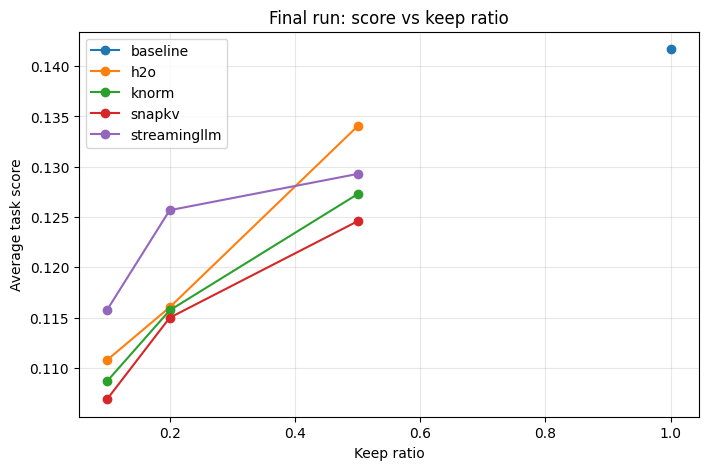

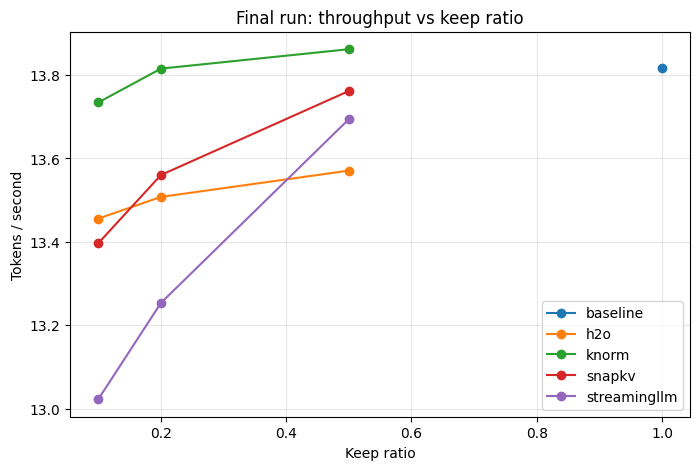

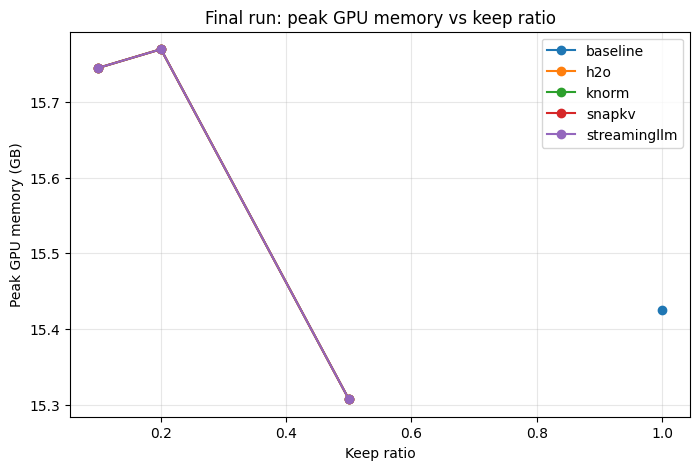

In [ ]:
# Final plots for the report.

if not final_overall_df.empty:
    plt.figure(figsize=(8, 5))
    for method in final_overall_df["method"].unique():
        sub = final_overall_df[final_overall_df["method"] == method].sort_values("keep_ratio")
        plt.plot(sub["keep_ratio"], sub["score_mean"], marker="o", label=method)
    plt.xlabel("Keep ratio")
    plt.ylabel("Average task score")
    plt.title("Final run: score vs keep ratio")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    for method in final_overall_df["method"].unique():
        sub = final_overall_df[final_overall_df["method"] == method].sort_values("keep_ratio")
        plt.plot(sub["keep_ratio"], sub["tps_mean"], marker="o", label=method)
    plt.xlabel("Keep ratio")
    plt.ylabel("Tokens / second")
    plt.title("Final run: throughput vs keep ratio")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    if final_overall_df["peak_memory_gb_mean"].notna().any():
        plt.figure(figsize=(8, 5))
        for method in final_overall_df["method"].unique():
            sub = final_overall_df[final_overall_df["method"] == method].sort_values("keep_ratio")
            plt.plot(sub["keep_ratio"], sub["peak_memory_gb_mean"], marker="o", label=method)
        plt.xlabel("Keep ratio")
        plt.ylabel("Peak GPU memory (GB)")
        plt.title("Final run: peak GPU memory vs keep ratio")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()